# Room Occupancy Estimation: Student Guide

Prepared by Engr. Jamie Eduardo Rosal, MSCpE

Run in order. These 12 steps match the DOCX/PDF guide and supersede the initial random-split-only report.

## 1. Understand the objectives

Goal: classify whether a room contains 0, 1, 2, or 3 people using environmental measurements. This is multiclass classification, not continuous regression.

Objective 1: develop the full-feature Random Forest. Objective 2: remove each of five sensor groups and retrain. Objective 3: compare ablation effects with individual and grouped feature importance.

A Random Forest combines decision trees. Ablation means removing one group, retraining, and comparing on exactly the same test rows. The proposal title is Random Forest-Based Sensor Ablation Analysis for Environmental Feature Contribution in Multiclass Room Occupancy Estimation.

Checkpoint: explain why the occupancy label must never be an input. This dataset cannot establish performance on occupancy counts outside 0-3.

In [1]:
print("Objectives: classify occupancy; compare five ablations; assess sensor contribution.")

Objectives: classify occupancy; compare five ablations; assess sensor contribution.


## 2. Prepare the environment

Materials: laptop/desktop, Python 3.12, JupyterLab, and the supplied Occupancy_Estimation.csv. A practical recommendation is 8 GB RAM, not a measured minimum. Internet is needed for installation only.

Open a terminal in this project folder. macOS/Linux: run python3.12 -m venv .venv and then source .venv/bin/activate. Windows Command Prompt: run py -3.12 -m venv .venv and then .venv\Scripts\activate.bat.

Run python -m pip install -r requirements.txt. Register the environment with python -m ipykernel install --user --name occupancy-guide --display-name "Occupancy Guide". Launch python -m jupyterlab, open Room_Occupancy_Estimation.ipynb, and select the Occupancy Guide kernel.

Use the same Python for installation and execution. This avoids the system-Python versus Anaconda mismatch encountered in the initial build. The local CSV makes ucimlrepo unnecessary.

Action: run the cell. Expected: Python executable and package versions. Checkpoint: resolve import errors before continuing; do not suppress warnings globally.

In [2]:
from pathlib import Path
import sys, json, hashlib, importlib.metadata as metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
SEED, LABELS = 42, [0, 1, 2, 3]
DATA = Path("Occupancy_Estimation.csv")
assert DATA.exists(), "Start Jupyter in the project folder containing the CSV."
OUT = Path("results")
OUT.mkdir(exist_ok=True)
(OUT / "repeatability_check.json").unlink(missing_ok=True)
(OUT / "verification_report.json").unlink(missing_ok=True)
versions = {p: metadata.version(p) for p in ["numpy", "pandas", "scikit-learn", "matplotlib"]}
print(sys.version, sys.executable, versions, sep="\n")

3.12.8 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 10:37:40) [Clang 14.0.6 ]
/opt/anaconda3/bin/python
{'numpy': '2.4.6', 'pandas': '3.0.1', 'scikit-learn': '1.9.0', 'matplotlib': '3.11.0'}


## 3. Load and validate the dataset

Action: read the CSV and define the sensor groups explicitly. There are 19 columns: Date, Time, 16 sensor features and the occupancy target. Sixteen features do not mean sixteen physical sensors.

Temperature: S1-S4 Temp. Light: S1-S4 Light. Sound: S1-S4 Sound. CO2: S5_CO2 and S5_CO2_Slope together. PIR: S6_PIR and S7_PIR. Consult UCI documentation for units/calibration rather than assuming them from column names.

Use Date/Time only for ordering and evaluation, not prediction. Preserve source-row identifiers. Missing targets, invalid timestamps, unexpected labels or duplicate timestamps stop execution. Remove exact duplicate rows before splitting and count them.

Missing sensor readings are allowed and later median-imputed using training data only. Infinite values become missing. Random Forest does not require scaling.

Expected: 10,129 rows, four labels and no missing values for the supplied CSV. Checkpoint: read the audit before accepting any result.

In [3]:
GROUPS = {"Temperature": [f"S{i}_Temp" for i in range(1, 5)],
          "Light": [f"S{i}_Light" for i in range(1, 5)],
          "Sound": [f"S{i}_Sound" for i in range(1, 5)],
          "CO2": ["S5_CO2", "S5_CO2_Slope"], "PIR": ["S6_PIR", "S7_PIR"]}
FEATURES = sum(GROUPS.values(), [])
TARGET = "Room_Occupancy_Count"
raw = pd.read_csv(DATA)
assert set(raw.columns) == set(FEATURES + ["Date", "Time", TARGET])
assert raw[TARGET].notna().all() and raw[TARGET].isin(LABELS).all()
duplicates = int(raw.duplicated().sum())
df = raw.loc[~raw.duplicated()].copy()
df["source_row"] = df.index + 2  # CSV line number including the header.
df["timestamp"] = pd.to_datetime(df.Date + " " + df.Time, format="%Y/%m/%d %H:%M:%S", errors="raise")
assert df.timestamp.notna().all(), "Date and Time must not be missing."
assert not df.timestamp.duplicated().any(), "Investigate duplicate timestamps."
df = df.sort_values("timestamp").reset_index(drop=True)
df[FEATURES] = df[FEATURES].apply(pd.to_numeric, errors="raise").replace([np.inf, -np.inf], np.nan)
pir = df[["S6_PIR", "S7_PIR"]]
assert (pir.isna() | pir.isin([0, 1])).all().all()
audit = {"raw_shape": list(raw.shape), "duplicate_rows_removed": duplicates,
         "missing_sensor_values": int(df[FEATURES].isna().sum().sum()),
         "sha256": hashlib.sha256(DATA.read_bytes()).hexdigest(),
         "class_counts": df[TARGET].value_counts().sort_index().to_dict()}
print(json.dumps(audit, indent=2))
display(df.head())
daily = pd.crosstab(df.timestamp.dt.date, df[TARGET]).reindex(columns=LABELS, fill_value=0)
display(daily)
daily.to_csv(OUT / "daily_class_counts.csv")

{
  "raw_shape": [
    10129,
    19
  ],
  "duplicate_rows_removed": 0,
  "missing_sensor_values": 0,
  "sha256": "c090ee5c94b61762bfec9d22767864490b51030f98cca030f02822468db25d9c",
  "class_counts": {
    "0": 8228,
    "1": 459,
    "2": 748,
    "3": 694
  }
}


,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,...,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count,source_row,timestamp
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,...,0.19,0.06,0.06,390,0.769231,0,0,1,2,2017-12-22 10:49:41
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,...,0.05,0.06,0.06,390,0.646154,0,0,1,3,2017-12-22 10:50:12
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,...,0.11,0.08,0.06,390,0.519231,0,0,1,4,2017-12-22 10:50:42
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,...,0.10,0.10,0.09,390,0.388462,0,0,1,5,2017-12-22 10:51:13
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,...,0.06,0.06,0.06,390,0.253846,0,0,1,6,2017-12-22 10:51:44


Room_Occupancy_Count,0,1,2,3
timestamp,,,,
2017-12-22,637,205,257,363
2017-12-23,1997,254,398,130
2017-12-24,1064,0,0,0
2017-12-25,1716,0,0,0
2017-12-26,1063,0,0,0
2018-01-10,703,0,93,201
2018-01-11,1048,0,0,0


## 4. Explore the training data

Action: inspect full-data class balance and timing as an audit. Use the first recorded day for detailed sensor exploration: it is training data in every temporal evaluation. Do not use later feature patterns to tune the model.

Plot sensor distributions and Pearson correlations. Count readings beyond 1.5 times the interquartile range (IQR), but do not delete them automatically. Genuine occupied periods may look unusual relative to empty periods.

Expected: empty-room readings dominate (about 81%). Several dates contain only class 0, and January has no class 1. Checkpoint: explain why accuracy alone is insufficient and why test-class coverage matters.

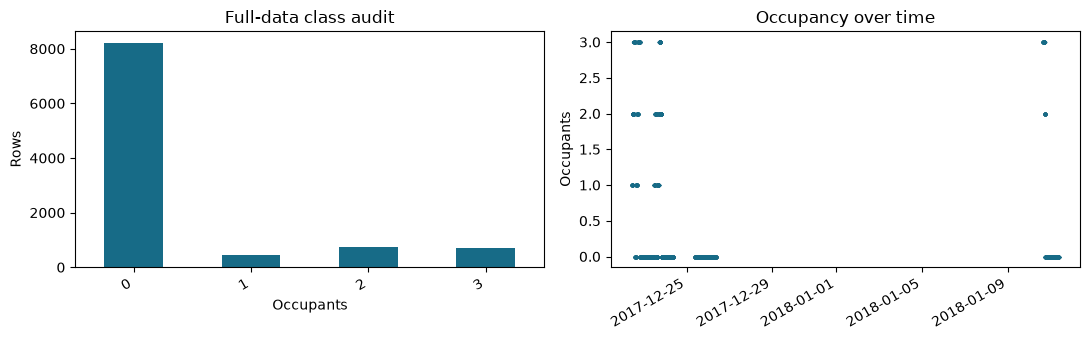

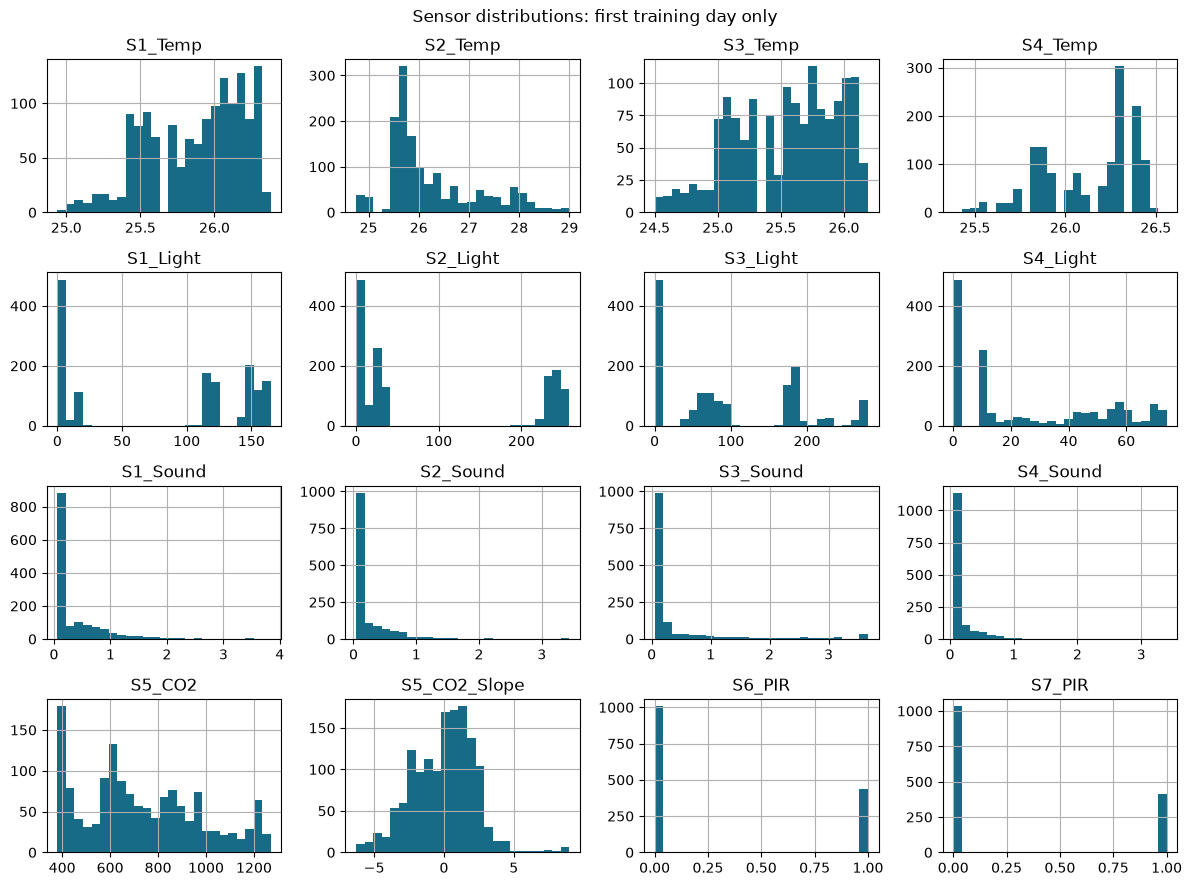

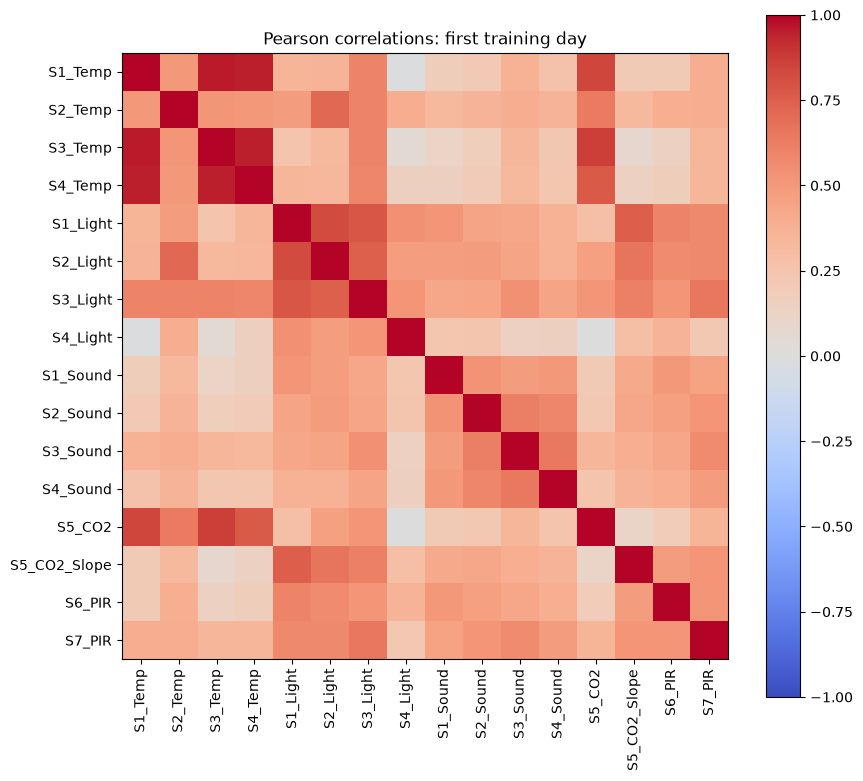

,IQR flags (not deleted)
S1_Temp,0
S2_Temp,85
S3_Temp,0
S4_Temp,0
S1_Light,0
S2_Light,0
S3_Light,0
S4_Light,0
S1_Sound,111
S2_Sound,154


In [4]:
def save_figure(name):
    plt.savefig(OUT / name, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
df[TARGET].value_counts().sort_index().plot.bar(ax=axes[0], color="#176b87")
axes[0].set(title="Full-data class audit", xlabel="Occupants", ylabel="Rows")
axes[1].scatter(df.timestamp, df[TARGET], s=2, color="#176b87")
axes[1].set(title="Occupancy over time", ylabel="Occupants")
fig.autofmt_xdate()
fig.tight_layout()
save_figure("class_timeline.png")
second_day = sorted(df.timestamp.dt.date.unique())[1]
eda_end = df.loc[df.timestamp.dt.date == second_day, "timestamp"].min() - pd.Timedelta(minutes=10)
eda = df.loc[(df.timestamp.dt.date == df.timestamp.dt.date.min()) & (df.timestamp < eda_end), FEATURES]
eda.hist(figsize=(12, 9), bins=25, color="#176b87")
plt.suptitle("Sensor distributions: first training day only")
plt.tight_layout()
save_figure("distributions.png")
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(eda.corr(), vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(16), FEATURES, rotation=90)
ax.set_yticks(range(16), FEATURES)
ax.set_title("Pearson correlations: first training day")
fig.colorbar(im, ax=ax)
fig.tight_layout()
save_figure("correlations.png")
q1, q3 = eda.quantile(.25), eda.quantile(.75)
iqr = q3 - q1
flags = ((eda < q1 - 1.5 * iqr) | (eda > q3 + 1.5 * iqr)).sum()
display(flags.rename("IQR flags (not deleted)").to_frame())
flags.to_csv(OUT / "outlier_audit.csv")

## 5. Define the controlled experiments

Action: compare All features with Without Temperature, Without Light, Without Sound, Without CO2, and Without PIR. A fresh pipeline is fitted for every experiment using identical split rows and model settings.

Use 100 trees, maximum depth 10, random seed 42, and max_features='sqrt', retaining the original settings. These are fixed instructional settings, not selected using test scores. Other key defaults are explicit below.

The sqrt rule is constant, but its effective candidate-feature count can change after removing columns. Ablation measures removal within this learning procedure, not a pure causal effect of a physical sensor.

Checkpoint: CO2 removal must include its slope. Date, Time, source_row, timestamp and the target must never enter X.

In [5]:
CONFIGS = {"All features": FEATURES}
CONFIGS.update({f"Without {g}": [f for f in FEATURES if f not in cols] for g, cols in GROUPS.items()})
PARAMS = dict(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1,
              criterion="gini", max_features="sqrt", bootstrap=True,
              min_samples_split=2, min_samples_leaf=1, class_weight=None)
display(pd.DataFrame([{"configuration": name, "n_features": len(cols),
                       "removed": "No group removed" if name == "All features" else name[8:]}
                      for name, cols in CONFIGS.items()]))
assert len(FEATURES) == len(set(FEATURES)) == 16

,configuration,n_features,removed
0,All features,16,No group removed
1,Without Temperature,12,Temperature
2,Without Light,12,Light
3,Without Sound,12,Sound
4,Without CO2,14,CO2
5,Without PIR,14,PIR


## 6. Create and audit the splits

Action: preserve the stratified random 80:20 split (seed 42) as a historical comparison, not evidence of future-session generalization. Neighboring readings can appear on both sides and are highly dependent.

Temporal holdout: train on December, test on January. This uses the natural multi-day recording gap. January has only classes 0, 2 and 3, so class-1 generalization cannot be assessed. No test scores are used to tune models.

Robustness: train on expanding past history and test each next recorded day, with a 10-minute embargo before that day's first test reading. This illustrative gap reduces immediate adjacency; it does not prove independence.

No fold is selected by performance. Separate occupied-day and empty-only-day summaries. Folds share training history and are not independent replications. The January holdout overlaps the final two daily tests, so these are alternative summaries, not independent confirmation.

Checkpoint: assert disjoint rows, temporal ordering and class coverage. Save exact source-row assignments. The cutoff and embargo are study design choices specific to this dataset, not optimized settings.

In [6]:
indices = np.arange(len(df))
tr, te = train_test_split(indices, test_size=.2, stratify=df[TARGET], random_state=SEED)
SPLITS = {"random_80_20": (tr, te)}
cutoff = pd.Timestamp("2018-01-01")
SPLITS["temporal_holdout"] = (indices[df.timestamp < cutoff], indices[df.timestamp >= cutoff])
dates = sorted(df.timestamp.dt.date.unique())
for day in dates[1:]:
    te = indices[df.timestamp.dt.date == day]
    tr = indices[df.timestamp < df.timestamp.iloc[te].min() - pd.Timedelta(minutes=10)]
    SPLITS[f"daily_{day}"] = (tr, te)
split_rows, assignment_rows = [], []
for name, (tr, te) in SPLITS.items():
    assert len(tr) and len(te) and not set(tr).intersection(te)
    assert set(df[TARGET].iloc[te]).issubset(set(df[TARGET].iloc[tr]))
    if name != "random_80_20":
        assert df.timestamp.iloc[tr].max() < df.timestamp.iloc[te].min()
    split_rows.append({"split": name, "train_rows": len(tr), "test_rows": len(te),
                       "train_end": str(df.timestamp.iloc[tr].max()),
                       "test_start": str(df.timestamp.iloc[te].min()),
                       "test_classes": ",".join(map(str, sorted(df[TARGET].iloc[te].unique()))),
                       **{f"train_class_{c}": int((df[TARGET].iloc[tr] == c).sum()) for c in LABELS},
                       **{f"test_class_{c}": int((df[TARGET].iloc[te] == c).sum()) for c in LABELS}})
    for role, rows in [("train", tr), ("test", te)]:
        assignment_rows.extend({"split": name, "role": role, "source_row": int(df.source_row.iloc[i])} for i in rows)
split_audit = pd.DataFrame(split_rows)
display(split_audit)
split_audit.to_csv(OUT / "split_audit.csv", index=False)
pd.DataFrame(assignment_rows).to_csv(OUT / "split_assignments.csv", index=False)

,split,train_rows,test_rows,train_end,test_start,test_classes,train_class_0,train_class_1,train_class_2,train_class_3,test_class_0,test_class_1,test_class_2,test_class_3
0,random_80_20,8103,2026,2018-01-11 09:00:09,2017-12-22 10:49:41,"0,1,2,3",6582,367,599,555,1646,92,149,139
1,temporal_holdout,8084,2045,2017-12-26 09:10:01,2018-01-10 15:25:48,"0,2,3",6477,459,655,493,1751,0,93,201
2,daily_2017-12-23,1444,2779,2017-12-22 23:50:22,2017-12-23 00:00:34,"0,1,2,3",619,205,257,363,1997,254,398,130
3,daily_2017-12-24,4224,1064,2017-12-23 23:50:43,2017-12-24 00:00:56,0,2617,459,655,493,1064,0,0,0
4,daily_2017-12-25,5305,1716,2017-12-24 09:10:50,2017-12-25 09:11:42,0,3698,459,655,493,1716,0,0,0
5,daily_2017-12-26,7003,1063,2017-12-25 23:50:25,2017-12-26 00:00:37,0,5396,459,655,493,1063,0,0,0
6,daily_2018-01-10,8084,997,2017-12-26 09:10:01,2018-01-10 15:25:48,"0,2,3",6477,459,655,493,703,0,93,201
7,daily_2018-01-11,9062,1048,2018-01-10 23:50:15,2018-01-11 00:00:28,0,7161,459,748,694,1048,0,0,0


## 7. Train and evaluate all configurations

Action: run 48 small forests, six configurations across eight splits. Runtime depends on your machine. The median imputer is fitted inside each training pipeline; no scaling or oversampling is required.

Accuracy is the fraction correct. Precision asks how often a predicted class is correct; recall asks how often an actual class is found. F1 balances precision and recall. Weighted averages weight by class support and are dominated by class 0 here. Weighted recall equals accuracy in this single-label task.

Macro-F1 is the arithmetic mean of per-class F1 values. Use the classes present in each test split for the primary within-split ablation comparison. Also export fixed-four-class macro-F1, assigning zero to absent classes, for transparency. The report label macro avg fixed4 explicitly identifies that alternative average. Never compare macro scores across splits without considering class coverage. A zero-support class is untested, not a measured failure.

Export per-class reports, confusion matrices and exact predictions for every experiment. Checkpoint: each confusion matrix sums to the test-row count. Do not retrain just to print a report.

In [7]:
rows, prediction_rows, reports, matrices = [], [], {}, {}
importance_tables = []
for split, (tr, te) in SPLITS.items():
    truth = df[TARGET].iloc[te]
    observed = sorted(truth.unique())
    reports[split], matrices[split] = {}, {}
    for name, cols in CONFIGS.items():
        assert df.iloc[tr][cols].notna().any().all(), "All-missing training feature."
        model = make_pipeline(SimpleImputer(strategy="median"), RandomForestClassifier(**PARAMS))
        model.fit(df.iloc[tr][cols], df[TARGET].iloc[tr])
        pred = model.predict(df.iloc[te][cols])
        pw, rw, fw, _ = precision_recall_fscore_support(truth, pred, average="weighted", zero_division=0)
        pm, rm, fm, _ = precision_recall_fscore_support(truth, pred, labels=observed, average="macro", zero_division=0)
        f4 = precision_recall_fscore_support(truth, pred, labels=LABELS, average="macro", zero_division=0)[2]
        rows.append({"split": split, "configuration": name, "features": len(cols),
                     "accuracy": accuracy_score(truth, pred), "precision_weighted": pw,
                     "recall_weighted": rw, "f1_weighted": fw,
                     "precision_macro_observed": pm, "recall_macro_observed": rm,
                     "f1_macro_observed": fm, "f1_macro_fixed4": f4,
                     "errors": int((truth.to_numpy() != pred).sum())})
        report = classification_report(truth, pred, labels=LABELS, output_dict=True, zero_division=0)
        report["macro avg fixed4"] = report.pop("macro avg")
        report["macro avg observed"] = {"precision": pm, "recall": rm, "f1-score": fm, "support": len(te)}
        reports[split][name] = report
        cm = confusion_matrix(truth, pred, labels=LABELS)
        assert cm.sum() == len(te)
        matrices[split][name] = cm.tolist()
        prediction_rows.extend({"split": split, "configuration": name,
                                "source_row": int(df.source_row.iloc[i]), "actual": int(y), "predicted": int(p)}
                               for i, y, p in zip(te, truth, pred))
        if name == "All features":
            importance_tables.extend({"split": split, "feature": f, "importance": float(v),
                                      "group": next(g for g, fs in GROUPS.items() if f in fs)}
                                     for f, v in zip(cols, model[-1].feature_importances_))
    print("Completed", split)
metrics = pd.DataFrame(rows)
base = metrics[metrics.configuration == "All features"].set_index("split")
metrics["accuracy_drop_pp"] = 100 * (metrics.split.map(base.accuracy) - metrics.accuracy)
metrics["macro_f1_drop_pp"] = 100 * (metrics.split.map(base.f1_macro_observed) - metrics.f1_macro_observed)
metrics.to_csv(OUT / "metrics.csv", index=False)
pd.DataFrame(prediction_rows).to_csv(OUT / "predictions.csv", index=False)
(OUT / "classification_reports.json").write_text(json.dumps(reports, indent=2))
(OUT / "confusion_matrices.json").write_text(json.dumps(matrices, indent=2))
display(metrics[metrics.split.isin(["random_80_20", "temporal_holdout"])])

Completed random_80_20


Completed temporal_holdout


Completed daily_2017-12-23


Completed daily_2017-12-24


Completed daily_2017-12-25


Completed daily_2017-12-26


Completed daily_2018-01-10


Completed daily_2018-01-11


,split,configuration,features,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro_observed,recall_macro_observed,f1_macro_observed,f1_macro_fixed4,errors,accuracy_drop_pp,macro_f1_drop_pp
0,random_80_20,All features,16,0.997038,0.997119,0.997038,0.997026,0.991731,0.989209,0.990284,0.990284,6,0.000000,0.000000
1,random_80_20,Without Temperature,12,0.997038,0.997119,0.997038,0.997026,0.991731,0.989209,0.990284,0.990284,6,0.000000,0.000000
2,random_80_20,Without Light,12,0.991609,0.991650,0.991609,0.991614,0.972992,0.969039,0.970950,0.970950,17,0.542942,1.933426
3,random_80_20,Without Sound,12,0.998026,0.998055,0.998026,0.998019,0.994914,0.992806,0.993783,0.993783,4,-0.098717,-0.349879
4,random_80_20,Without CO2,14,0.997532,0.997584,0.997532,0.997523,0.993312,0.991007,0.992034,0.992034,5,-0.049358,-0.175011
5,random_80_20,Without PIR,14,0.997532,0.997584,0.997532,0.997523,0.993312,0.991007,0.992034,0.992034,5,-0.049358,-0.175011
6,temporal_holdout,All features,16,0.880196,0.837689,0.880196,0.848187,0.684019,0.480073,0.528768,0.396576,245,0.000000,0.000000
7,temporal_holdout,Without Temperature,12,0.869438,0.832549,0.869438,0.833540,0.661614,0.399294,0.422210,0.316657,267,1.075795,10.655849
8,temporal_holdout,Without Light,12,0.881174,0.888767,0.881174,0.878710,0.486504,0.501369,0.464906,0.348679,243,-0.097800,6.386245
9,temporal_holdout,Without Sound,12,0.882641,0.841275,0.882641,0.851240,0.701540,0.496068,0.547829,0.410872,240,-0.244499,-1.906065


## 8. Inspect errors and ablation changes

Action: inspect all six confusion matrices for the random comparison and temporal holdout. Rows are true labels, columns predictions. Off-diagonal entries are mistakes; an empty true-label row means there were no examples, not perfect recall.

Positive drop means removal worsens performance; negative means improvement. Drops use percentage points: 99.70% minus 99.16% is about 0.54 percentage points, not a relative decrease of 0.54%.

Checkpoint: examine occupied-class errors rather than just correct-empty-room counts. The baseline bar is colored by name, regardless of sorting. Full per-class reports for all configurations are saved in classification_reports.json.

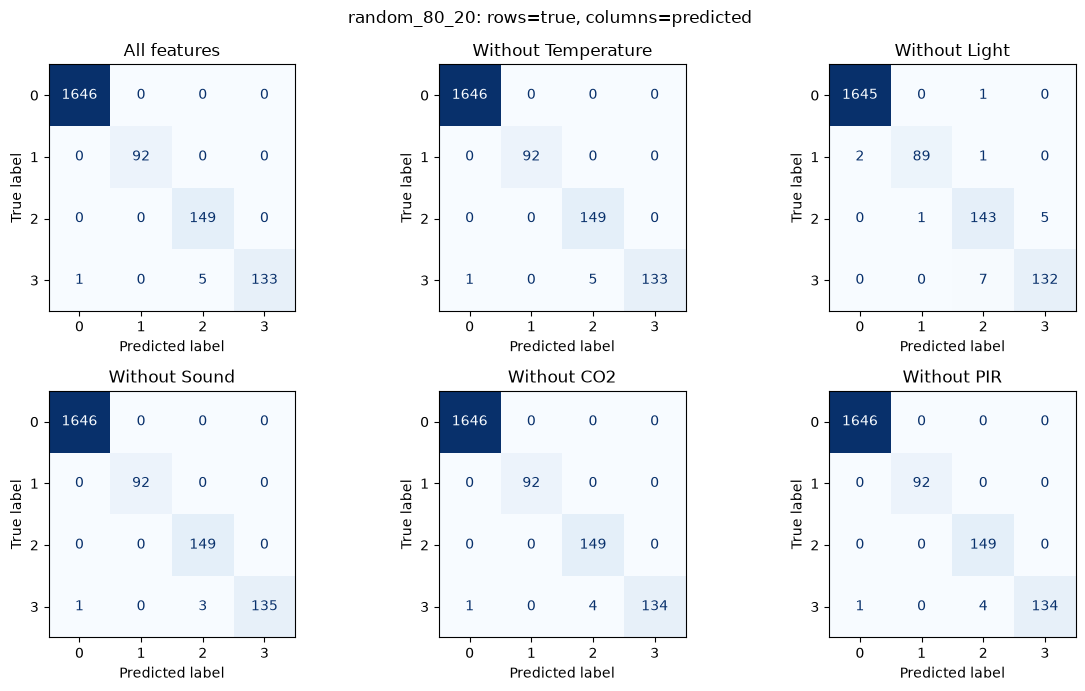

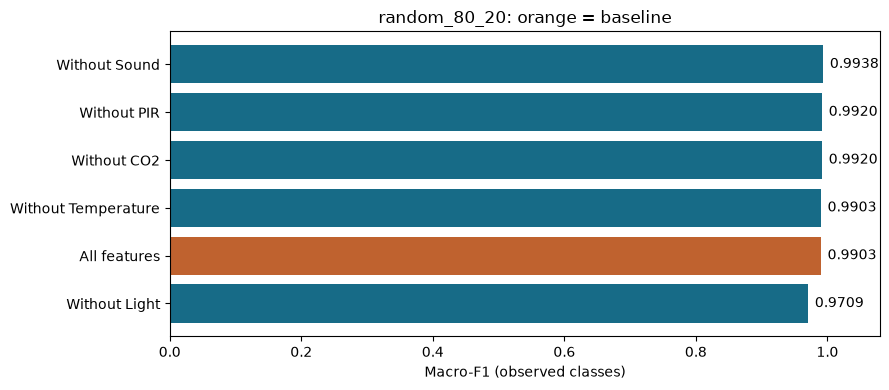

random_80_20 All features per-class report: support=0 means untested


,precision,recall,f1-score,support
0,0.999393,1.000000,0.999696,1646.000000
1,1.000000,1.000000,1.000000,92.000000
2,0.967532,1.000000,0.983498,149.000000
3,1.000000,0.956835,0.977941,139.000000
accuracy,0.997038,0.997038,0.997038,0.997038
weighted avg,0.997119,0.997038,0.997026,2026.000000
macro avg fixed4,0.991731,0.989209,0.990284,2026.000000
macro avg observed,0.991731,0.989209,0.990284,2026.000000


random_80_20 Without Temperature per-class report: support=0 means untested


,precision,recall,f1-score,support
0,0.999393,1.000000,0.999696,1646.000000
1,1.000000,1.000000,1.000000,92.000000
2,0.967532,1.000000,0.983498,149.000000
3,1.000000,0.956835,0.977941,139.000000
accuracy,0.997038,0.997038,0.997038,0.997038
weighted avg,0.997119,0.997038,0.997026,2026.000000
macro avg fixed4,0.991731,0.989209,0.990284,2026.000000
macro avg observed,0.991731,0.989209,0.990284,2026.000000


random_80_20 Without Light per-class report: support=0 means untested


...

,precision,recall,f1-score,support
0,0.999393,1.000000,0.999696,1646.000000
1,1.000000,1.000000,1.000000,92.000000
2,0.980263,1.000000,0.990033,149.000000
3,1.000000,0.971223,0.985401,139.000000
accuracy,0.998026,0.998026,0.998026,0.998026
weighted avg,0.998055,0.998026,0.998019,2026.000000
macro avg fixed4,0.994914,0.992806,0.993783,2026.000000
macro avg observed,0.994914,0.992806,0.993783,2026.000000


random_80_20 Without CO2 per-class report: support=0 means untested


,precision,recall,f1-score,support
0,0.999393,1.000000,0.999696,1646.000000
1,1.000000,1.000000,1.000000,92.000000
2,0.973856,1.000000,0.986755,149.000000
3,1.000000,0.964029,0.981685,139.000000
accuracy,0.997532,0.997532,0.997532,0.997532
weighted avg,0.997584,0.997532,0.997523,2026.000000
macro avg fixed4,0.993312,0.991007,0.992034,2026.000000
macro avg observed,0.993312,0.991007,0.992034,2026.000000


random_80_20 Without PIR per-class report: support=0 means untested


,precision,recall,f1-score,support
0,0.999393,1.000000,0.999696,1646.000000
1,1.000000,1.000000,1.000000,92.000000
2,0.973856,1.000000,0.986755,149.000000
3,1.000000,0.964029,0.981685,139.000000
accuracy,0.997532,0.997532,0.997532,0.997532
weighted avg,0.997584,0.997532,0.997523,2026.000000
macro avg fixed4,0.993312,0.991007,0.992034,2026.000000
macro avg observed,0.993312,0.991007,0.992034,2026.000000


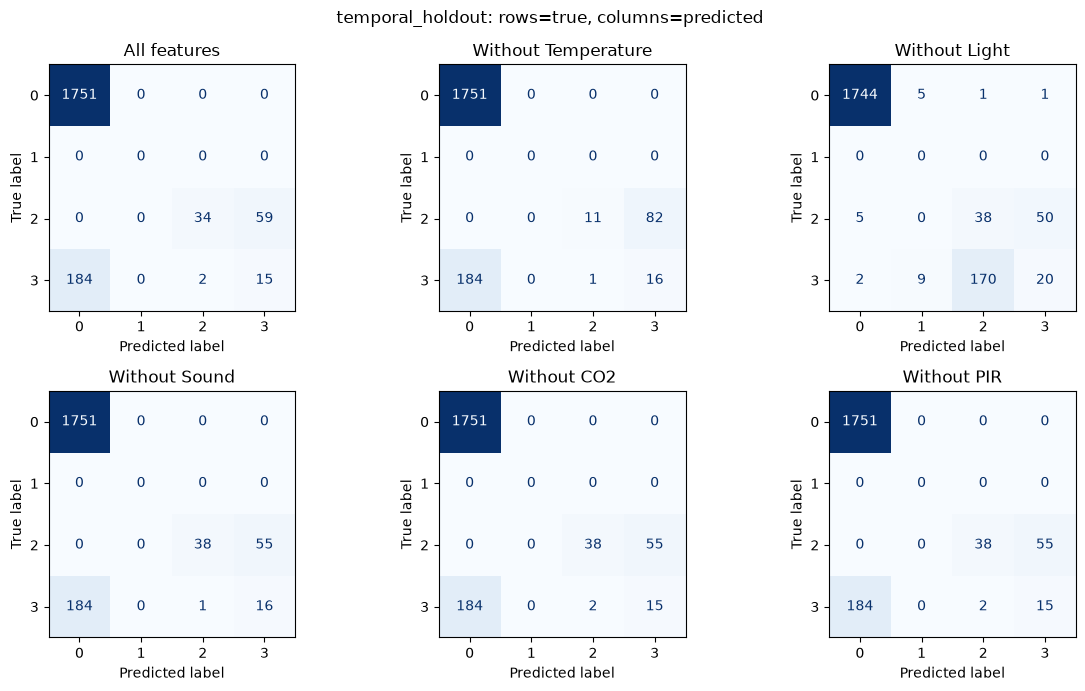

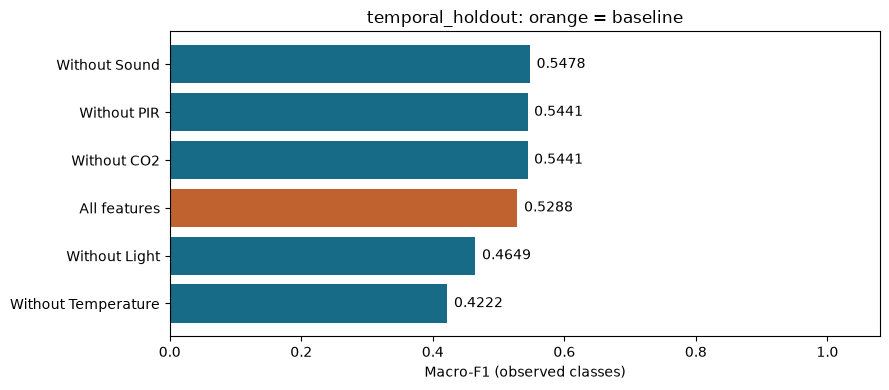

temporal_holdout All features per-class report: support=0 means untested


,precision,recall,f1-score,support
0,0.904910,1.000000,0.950081,1751.000000
1,0.000000,0.000000,0.000000,0.000000
2,0.944444,0.365591,0.527132,93.000000
3,0.202703,0.074627,0.109091,201.000000
accuracy,0.880196,0.880196,0.880196,0.880196
weighted avg,0.837689,0.880196,0.848187,2045.000000
macro avg fixed4,0.513014,0.360055,0.396576,2045.000000
macro avg observed,0.684019,0.480073,0.528768,2045.000000


temporal_holdout Without Temperature per-class report: support=0 means untested


,precision,recall,f1-score,support
0,0.904910,1.000000,0.950081,1751.000000
1,0.000000,0.000000,0.000000,0.000000
2,0.916667,0.118280,0.209524,93.000000
3,0.163265,0.079602,0.107023,201.000000
accuracy,0.869438,0.869438,0.869438,0.869438
weighted avg,0.832549,0.869438,0.833540,2045.000000
macro avg fixed4,0.496210,0.299470,0.316657,2045.000000
macro avg observed,0.661614,0.399294,0.422210,2045.000000


temporal_holdout Without Light per-class report: support=0 means untested


...

,precision,recall,f1-score,support
0,0.904910,1.000000,0.950081,1751.000000
1,0.000000,0.000000,0.000000,0.000000
2,0.974359,0.408602,0.575758,93.000000
3,0.225352,0.079602,0.117647,201.000000
accuracy,0.882641,0.882641,0.882641,0.882641
weighted avg,0.841275,0.882641,0.851240,2045.000000
macro avg fixed4,0.526155,0.372051,0.410872,2045.000000
macro avg observed,0.701540,0.496068,0.547829,2045.000000


temporal_holdout Without CO2 per-class report: support=0 means untested


,precision,recall,f1-score,support
0,0.904910,1.000000,0.950081,1751.000000
1,0.000000,0.000000,0.000000,0.000000
2,0.950000,0.408602,0.571429,93.000000
3,0.214286,0.074627,0.110701,201.000000
accuracy,0.882152,0.882152,0.882152,0.882152
weighted avg,0.839080,0.882152,0.850360,2045.000000
macro avg fixed4,0.517299,0.370807,0.408053,2045.000000
macro avg observed,0.689732,0.494410,0.544070,2045.000000


temporal_holdout Without PIR per-class report: support=0 means untested


,precision,recall,f1-score,support
0,0.904910,1.000000,0.950081,1751.000000
1,0.000000,0.000000,0.000000,0.000000
2,0.950000,0.408602,0.571429,93.000000
3,0.214286,0.074627,0.110701,201.000000
accuracy,0.882152,0.882152,0.882152,0.882152
weighted avg,0.839080,0.882152,0.850360,2045.000000
macro avg fixed4,0.517299,0.370807,0.408053,2045.000000
macro avg observed,0.689732,0.494410,0.544070,2045.000000


In [8]:
for split in ["random_80_20", "temporal_holdout"]:
    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    for ax, name in zip(axes.flat, CONFIGS):
        ConfusionMatrixDisplay(np.array(matrices[split][name]), display_labels=LABELS).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(name)
    fig.suptitle(split + ": rows=true, columns=predicted")
    fig.tight_layout()
    save_figure(f"confusion_{split}.png")
    subset = metrics[metrics.split == split].sort_values("f1_macro_observed")
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(subset.configuration, subset.f1_macro_observed,
            color=["#bf622f" if n == "All features" else "#176b87" for n in subset.configuration])
    ax.set(xlim=(0, 1.08), xlabel="Macro-F1 (observed classes)", title=split + ": orange = baseline")
    for i, value in enumerate(subset.f1_macro_observed):
        ax.text(value + .01, i, f"{value:.4f}", va="center")
    fig.tight_layout()
    save_figure(f"comparison_{split}.png")
    for name in CONFIGS:
        print(split, name, "per-class report: support=0 means untested")
        display(pd.DataFrame(reports[split][name]).T)

## 9. Analyze feature and group importance

Action: rank baseline impurity-based feature importance and sum within groups for both principal splits. These describe the trained forest, not causality or standalone sensor usefulness.

Impurity importance can favor features with many distinct values. Correlated inputs may substitute for one another. A feature can be important in the full model yet have a small ablation penalty because retraining lets other inputs replace it. Group sums also depend on group size.

Checkpoint: use ablation as main conditional-contribution evidence and importance as support. Do not declare Sound noisy merely because removing it improves a score.

,split,feature,importance,group
4,random_80_20,S1_Light,0.221655,Light
5,random_80_20,S2_Light,0.140150,Light
8,random_80_20,S1_Sound,0.114276,Sound
13,random_80_20,S5_CO2_Slope,0.103172,CO2
6,random_80_20,S3_Light,0.094086,Light
9,random_80_20,S2_Sound,0.079078,Sound
10,random_80_20,S3_Sound,0.050824,Sound
12,random_80_20,S5_CO2,0.044904,CO2
1,random_80_20,S2_Temp,0.034610,Temperature
0,random_80_20,S1_Temp,0.031592,Temperature


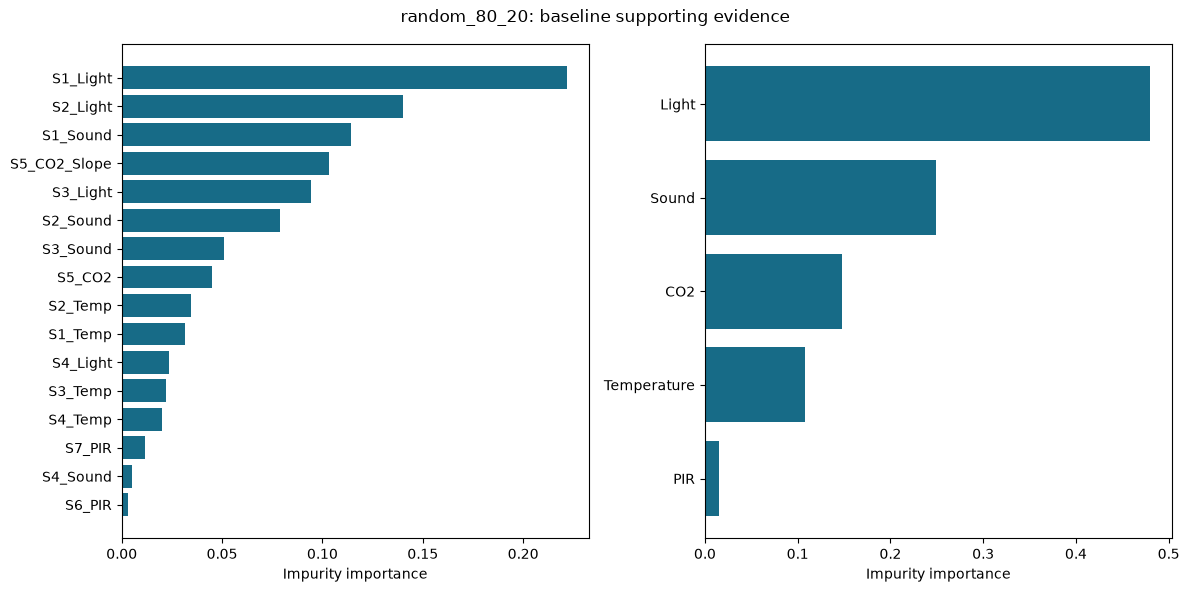

,split,feature,importance,group
20,temporal_holdout,S1_Light,0.231957,Light
21,temporal_holdout,S2_Light,0.190590,Light
22,temporal_holdout,S3_Light,0.109834,Light
24,temporal_holdout,S1_Sound,0.088140,Sound
29,temporal_holdout,S5_CO2_Slope,0.080716,CO2
28,temporal_holdout,S5_CO2,0.064799,CO2
25,temporal_holdout,S2_Sound,0.051625,Sound
26,temporal_holdout,S3_Sound,0.051368,Sound
18,temporal_holdout,S3_Temp,0.028043,Temperature
16,temporal_holdout,S1_Temp,0.027054,Temperature


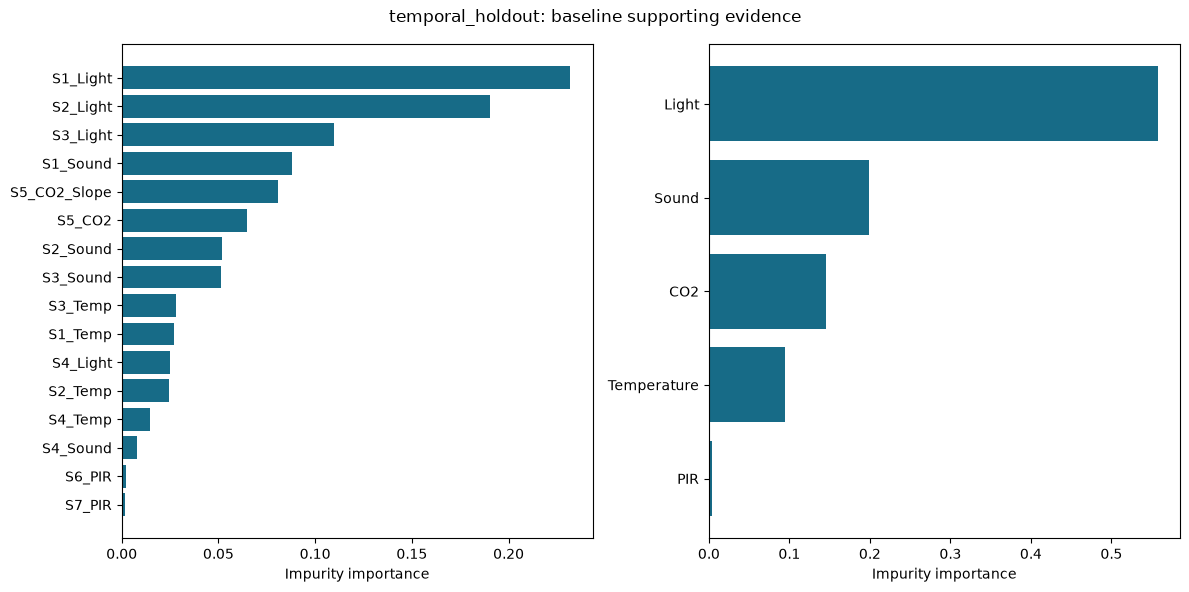

In [9]:
importance = pd.DataFrame(importance_tables)
group_importance = importance.groupby(["split", "group"], as_index=False).importance.sum()
assert np.allclose(group_importance.groupby("split").importance.sum(), 1)
importance.to_csv(OUT / "feature_importance.csv", index=False)
group_importance.to_csv(OUT / "group_importance.csv", index=False)
for split in ["random_80_20", "temporal_holdout"]:
    display(importance[importance.split == split].sort_values("importance", ascending=False))
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    for ax, frame, label in [(axes[0], importance, "feature"), (axes[1], group_importance, "group")]:
        part = frame[frame.split == split].sort_values("importance")
        ax.barh(part[label], part.importance, color="#176b87")
        ax.set_xlabel("Impurity importance")
    fig.suptitle(split + ": baseline supporting evidence")
    fig.tight_layout()
    save_figure(f"importance_{split}.png")

## 10. Assess robustness across days

Action: summarize paired ablation drops within expanding-history daily folds. Report mean, sample standard deviation, minimum and maximum, separating occupied-present from empty-only days. Days are weighted equally, unlike pooled row-level scoring.

Only two daily test folds include occupied readings; four are empty-only. Test classes differ and training history overlaps. The spread is descriptive variability, not a confidence interval or statistical significance test. Repeating random seeds alone would not resolve temporal leakage.

Checkpoint: does the ranking change between random and temporal evaluations? Do not claim a universal most/least essential group when the evidence differs. Future work needs more independent occupied sessions and verification that the supplied CO2 slope is computed causally for real-time use.

In [10]:
daily_metrics = metrics[metrics.split.str.startswith("daily_")].copy()
test_classes = split_audit.set_index("split").test_classes
daily_metrics["day_type"] = daily_metrics.split.map(test_classes).map(lambda s: "empty-only" if s == "0" else "occupied-present")
robustness = (daily_metrics.groupby(["day_type", "configuration"])["macro_f1_drop_pp"]
              .agg(["count", "mean", "std", "min", "max"]).reset_index())
robustness.to_csv(OUT / "robustness.csv", index=False)
display(robustness)
display(daily_metrics[["split", "configuration", "accuracy", "f1_macro_observed", "macro_f1_drop_pp", "day_type"]])

,day_type,configuration,count,mean,std,min,max
0,empty-only,All features,4,0.000000,0.000000,0.000000,0.000000
1,empty-only,Without CO2,4,0.000000,0.000000,0.000000,0.000000
2,empty-only,Without Light,4,0.488636,0.827741,0.000000,1.719028
3,empty-only,Without PIR,4,0.000000,0.000000,0.000000,0.000000
4,empty-only,Without Sound,4,0.000000,0.000000,0.000000,0.000000
5,empty-only,Without Temperature,4,0.000000,0.000000,0.000000,0.000000
6,occupied-present,All features,2,0.000000,0.000000,0.000000,0.000000
7,occupied-present,Without CO2,2,-1.569113,0.054984,-1.607992,-1.530233
8,occupied-present,Without Light,2,22.362506,25.414968,4.391410,40.333602
9,occupied-present,Without PIR,2,-0.142047,1.963192,-1.530233,1.246140


,split,configuration,accuracy,f1_macro_observed,macro_f1_drop_pp,day_type
12,daily_2017-12-23,All features,0.949622,0.926646,0.000000,occupied-present
13,daily_2017-12-23,Without Temperature,0.957899,0.945619,-1.897269,occupied-present
14,daily_2017-12-23,Without Light,0.543001,0.523310,40.333602,occupied-present
15,daily_2017-12-23,Without Sound,0.945304,0.924958,0.168788,occupied-present
16,daily_2017-12-23,Without CO2,0.975531,0.942726,-1.607992,occupied-present
17,daily_2017-12-23,Without PIR,0.952501,0.914185,1.246140,occupied-present
18,daily_2017-12-24,All features,1.000000,1.000000,0.000000,empty-only
19,daily_2017-12-24,Without Temperature,1.000000,1.000000,0.000000,empty-only
20,daily_2017-12-24,Without Light,0.995301,0.997645,0.235516,empty-only
21,daily_2017-12-24,Without Sound,1.000000,1.000000,0.000000,empty-only


## 11. Write evidence-based conclusions

Action: report the exact split, test-class support, baseline scores and the largest/smallest observed ablation drops. Smallest does not prove dispensability. Zero or negative drops do not establish lack of information.

The initial random split classified 2,020 of 2,026 correctly. Removing Sound improved two predictions, not evidence of noise reduction. Compare the regenerated table instead of assuming time-separated evaluation preserves that ranking.

Limitations: one room, few recording days, temporal dependence, severe imbalance, absent class 1 in January, unverified real-time availability of CO2 slope and no external validation. This is offline classification, not a certified occupancy or safety system.

Checkpoint: address all three objectives while stating where evidence is insufficient. More occupied-session data is a recommendation, not an already completed experiment.

In [11]:
conclusions = []
for split in ["random_80_20", "temporal_holdout"]:
    b = base.loc[split]
    ab = metrics[(metrics.split == split) & (metrics.configuration != "All features")]
    largest = ab.loc[ab.macro_f1_drop_pp.idxmax()]
    smallest = ab.loc[ab.macro_f1_drop_pp.idxmin()]
    text = (f"{split}: baseline accuracy={b.accuracy:.4%}, macro-F1 observed={b.f1_macro_observed:.4f}; "
            f"largest observed macro-F1 drop: {largest.configuration} ({largest.macro_f1_drop_pp:+.3f} pp); "
            f"smallest: {smallest.configuration} ({smallest.macro_f1_drop_pp:+.3f} pp). "
            "These are conditional effects, not universal sensor-necessity rankings.")
    conclusions.append(text)
    print(text)
(OUT / "conclusions.json").write_text(json.dumps(conclusions, indent=2))

random_80_20: baseline accuracy=99.7038%, macro-F1 observed=0.9903; largest observed macro-F1 drop: Without Light (+1.933 pp); smallest: Without Sound (-0.350 pp). These are conditional effects, not universal sensor-necessity rankings.
temporal_holdout: baseline accuracy=88.0196%, macro-F1 observed=0.5288; largest observed macro-F1 drop: Without Temperature (+10.656 pp); smallest: Without Sound (-1.906 pp). These are conditional effects, not universal sensor-necessity rankings.


495

## 12. Reproduce and submit

Action: choose Restart Kernel and Run All Cells in Jupyter. Wait for completion and inspect outputs and warnings. The notebook overwrites its named outputs in results/. Never edit scores manually.

To rebuild the notebook and guides, run python build_materials.py. To regenerate guides after running the notebook, run python build_materials.py --documents-only. To execute twice and compare all numeric experiment outputs, run python build_materials.py --verify.

Keep requirements.txt, build_materials.py, notebook, CSV and results/ together. The DOCX opens in Word or imports into Google Docs; this does not create an online Google Doc. Older root-level reports and result CSVs are superseded by the current guide and results/.

Submission checklist: executed notebook; DOCX/PDF guide; checksum and versions; split audit/assignments; all six configurations per split; per-class reports/matrices; individual/group importance; robustness summaries; qualified conclusions.

Student questions: Why can random splitting inflate sensor-data performance? Why does weighted recall equal accuracy? How can a feature be important but have little ablation impact? Why is January class-1 recall untested? What further data supports deployment?

Troubleshooting: FileNotFoundError means working directory or CSV path is wrong. ModuleNotFoundError often means packages and kernel use different environments. Invalid labels/timestamps require investigation, not disabling assertions. PDF generation uses ReportLab and needs no LaTeX, browser or Pango.

Checkpoint: manifest and assertions must complete. Identical numeric results are expected in the same tested environment; different library versions can change results. The pinned file records direct dependencies, not every transitive package.

References: supplied Intro-to-AI-Proposal.docx; UCI Room Occupancy Estimation dataset, https://archive.ics.uci.edu/dataset/864/room+occupancy+estimation ; scikit-learn RandomForestClassifier, classification metrics and common pitfalls documentation, https://scikit-learn.org/stable/ .

In [12]:
assert len(metrics) == len(CONFIGS) * len(SPLITS) == 48
assert np.allclose(metrics.accuracy, metrics.recall_weighted)
assert (metrics.loc[metrics.configuration == "All features", "macro_f1_drop_pp"] == 0).all()
manifest = {"python": sys.version, "versions": versions, "dataset": audit,
            "builder_sha256": hashlib.sha256(Path("build_materials.py").read_bytes()).hexdigest(),
            "random_seed": SEED, "forest_parameters": PARAMS,
            "temporal_cutoff": str(cutoff), "daily_embargo_minutes": 10,
            "configurations": CONFIGS, "split_count": len(SPLITS),
            "author": "Prepared by Engr. Jamie Eduardo Rosal, MSCpE"}
(OUT / "manifest.json").write_text(json.dumps(manifest, indent=2))
print("Completed: 48 experiments; outputs and manifest saved in results/.")

Completed: 48 experiments; outputs and manifest saved in results/.
